In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
regions = ["PIVC", "TPJ", "Hippocampus", "Parietal", "Cerebellum", "Insula"]

scores = pd.DataFrame({
    "region": regions,
    "association_strength": [0.62, 0.55, 0.68, 0.51, 0.39, 0.44]
})

scores

,region,association_strength
0,PIVC,0.62
1,TPJ,0.55
2,Hippocampus,0.68
3,Parietal,0.51
4,Cerebellum,0.39
5,Insula,0.44


In [4]:
rows = []

for _, row in scores.iterrows():
    samples = np.random.normal(row["association_strength"], 0.10, 1000)
    rows.append([
        row["region"],
        samples.mean(),
        np.percentile(samples, 2.5),
        np.percentile(samples, 97.5)
    ])

boot = pd.DataFrame(
    rows,
    columns=["region", "boot_mean", "ci_low", "ci_high"]
)

boot

,region,boot_mean,ci_low,ci_high
0,PIVC,0.621933,0.435847,0.811080
1,TPJ,0.557084,0.363325,0.756153
2,Hippocampus,0.680583,0.488756,0.875437
3,Parietal,0.508128,0.307359,0.705374
4,Cerebellum,0.385073,0.180947,0.562677
5,Insula,0.435326,0.239922,0.643603


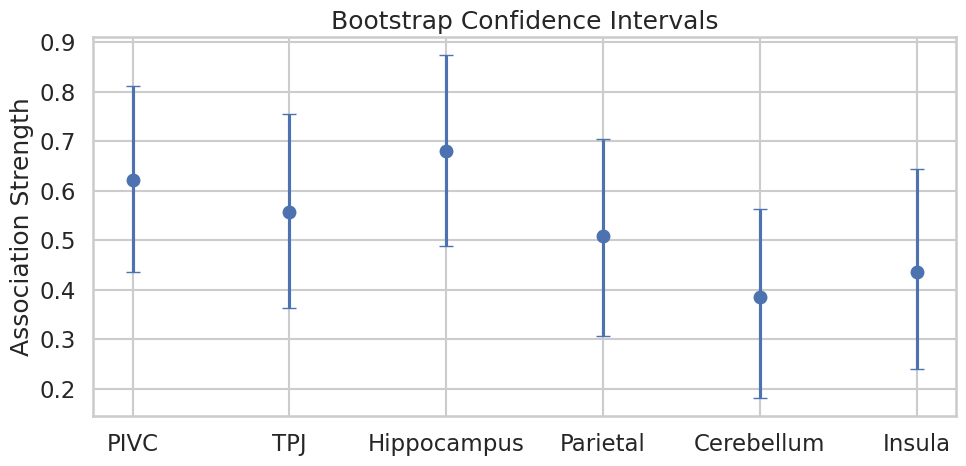

In [5]:
plt.figure(figsize=(10,5))

plt.errorbar(
    x=boot["region"],
    y=boot["boot_mean"],
    yerr=[
        boot["boot_mean"] - boot["ci_low"],
        boot["ci_high"] - boot["boot_mean"]
    ],
    fmt="o",
    capsize=5
)

plt.xlabel("")
plt.ylabel("Association Strength")
plt.title("Bootstrap Confidence Intervals")
plt.tight_layout()
plt.savefig("figures/05_bootstrap_ci.png", dpi=300)
plt.show()

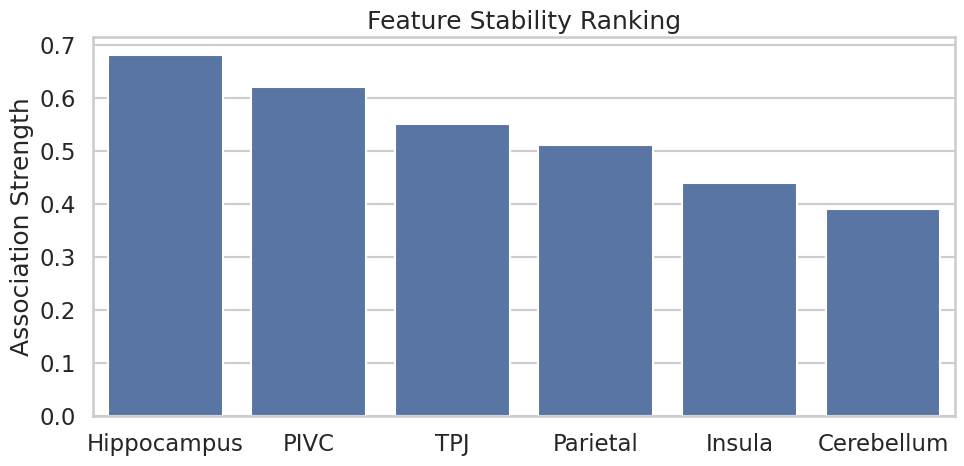

In [7]:
scores["rank"] = scores["association_strength"].rank(ascending=False).astype(int)

plt.figure(figsize=(10,5))

sns.barplot(
    data=scores.sort_values("association_strength", ascending=False),
    x="region",
    y="association_strength"
)

plt.xlabel("")
plt.ylabel("Association Strength")
plt.title("Feature Stability Ranking")
plt.tight_layout()
plt.savefig("figures/05_feature_ranking.png", dpi=300)
plt.show()

In [8]:
boot.to_csv("outputs/05_bootstrap_summary.csv", index=False)
scores.to_csv("outputs/05_feature_stability.csv", index=False)

scores.sort_values("rank")

,region,association_strength,rank
2,Hippocampus,0.68,1
0,PIVC,0.62,2
1,TPJ,0.55,3
3,Parietal,0.51,4
5,Insula,0.44,5
4,Cerebellum,0.39,6
